## Loading dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")

print("Path to dataset files:", path)

/Users/lipuze/miniconda3/envs/brain/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/lipuze/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1


In [2]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

In [3]:

# List files in the downloaded dataset
files = os.listdir(path)
print("Dataset files:", files)

Dataset files: ['music_genre.csv']


In [4]:
#Load data
df = pd.read_csv("./music_genre.csv")

## Data preprocessing

##### Take a look at the dataframe

In [5]:
df.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [6]:
df.shape

(50005, 18)

#### Remove rows where data is incomplete

In [7]:
bad_values = ['', ' ', '?' ,-1 ,'-1']
rows_to_drop = df.isna() | df.isin(bad_values)
df = df[~rows_to_drop.any(axis=1)]
df.shape

(40560, 18)

### Remove duplicated rows

Removing rows which have all columns the same, meaning duplicate data.

In [8]:
duplicate_rows = df.duplicated()
if duplicate_rows.sum() > 0:
    print("\nDuplicate rows:")
    print(df[duplicate_rows])
    df = df.drop_duplicates().reset_index(drop=True)
df.shape

(40560, 18)

For the models, there should not be two songs with the same artist name and track name with different non-numeric values, for example, key, genre or mode.

In [9]:
key_columns = ['artist_name', 'track_name']
target_col = 'music_genre'
subset_duplicates = df.duplicated(subset=key_columns)
print(f"Duplicates based on {key_columns}: {subset_duplicates.sum()}")
print(df[df.duplicated(subset=key_columns, keep=False)].sort_values(key_columns))

Duplicates based on ['artist_name', 'track_name']: 2593
       instance_id       artist_name                  track_name  popularity  \
3240       83947.0               !!!  Even When The Water's Cold        61.0   
17469      51893.0               !!!  Even When The Water's Cold        52.0   
28832      81298.0       $uicideBoy$                    2nd Hand        74.0   
47807      53674.0       $uicideBoy$                    2nd Hand        74.0   
26834      55684.0       $uicideBoy$      Do You Believe In God?        65.0   
...            ...               ...                         ...         ...   
48575      26618.0  nothing,nowhere.         Clarity In Kerosene        54.0   
28752      25949.0  nothing,nowhere.       I'm Sorry, I'm Trying        60.0   
46796      40229.0  nothing,nowhere.       I'm Sorry, I'm Trying        60.0   
26776      54743.0  nothing,nowhere.                     Letdown        61.0   
49631      66770.0  nothing,nowhere.                     Letdown

In [10]:
non_numeric_cols = df.select_dtypes(exclude='number').columns.difference(key_columns)

conflicting_non_numeric_mask = (
    df.groupby(key_columns)[non_numeric_cols]
      .transform(lambda col: col.nunique(dropna=False) > 1)
      .any(axis=1)
)
df = df[~conflicting_non_numeric_mask].reset_index(drop=True)
df.shape

(35480, 18)

Need to check for outliers, to make sure they are dropped. For example, if a song has duration in the negatives or is too long.

In [11]:
print(df['duration_ms'].nlargest(10).to_string(index=False))


4497994.0
4276000.0
3195440.0
2764934.0
2294000.0
2019293.0
1935787.0
1872653.0
1778440.0
1617333.0


In [12]:
print(df['duration_ms'].nsmallest(10).to_string(index=False))


15509.0
16316.0
19693.0
20096.0
22750.0
24000.0
26293.0
26717.0
27179.0
28947.0


These values are within acceptable ranges, so there is no need to drop them.

In [13]:
# save the cleaned data to csv
df.to_csv("./music_genre_cleaned.csv")

## Visualising the dataset

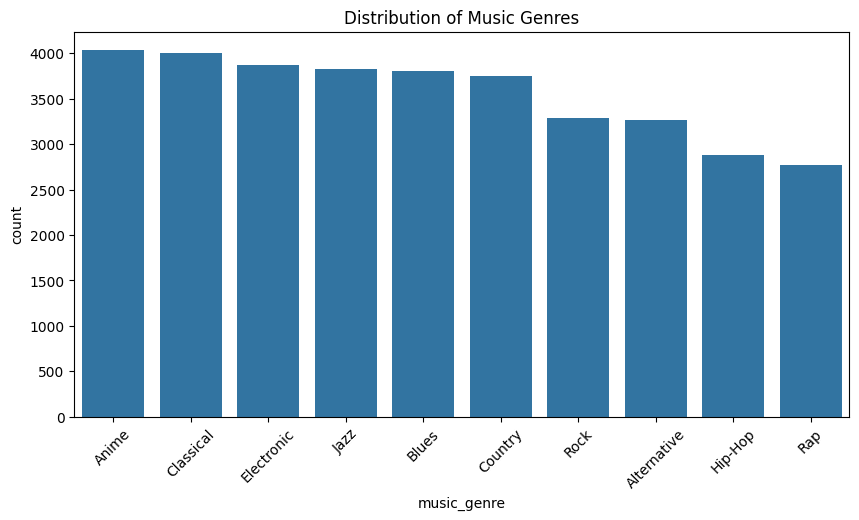

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='music_genre', order=df['music_genre'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of Music Genres')
plt.show()

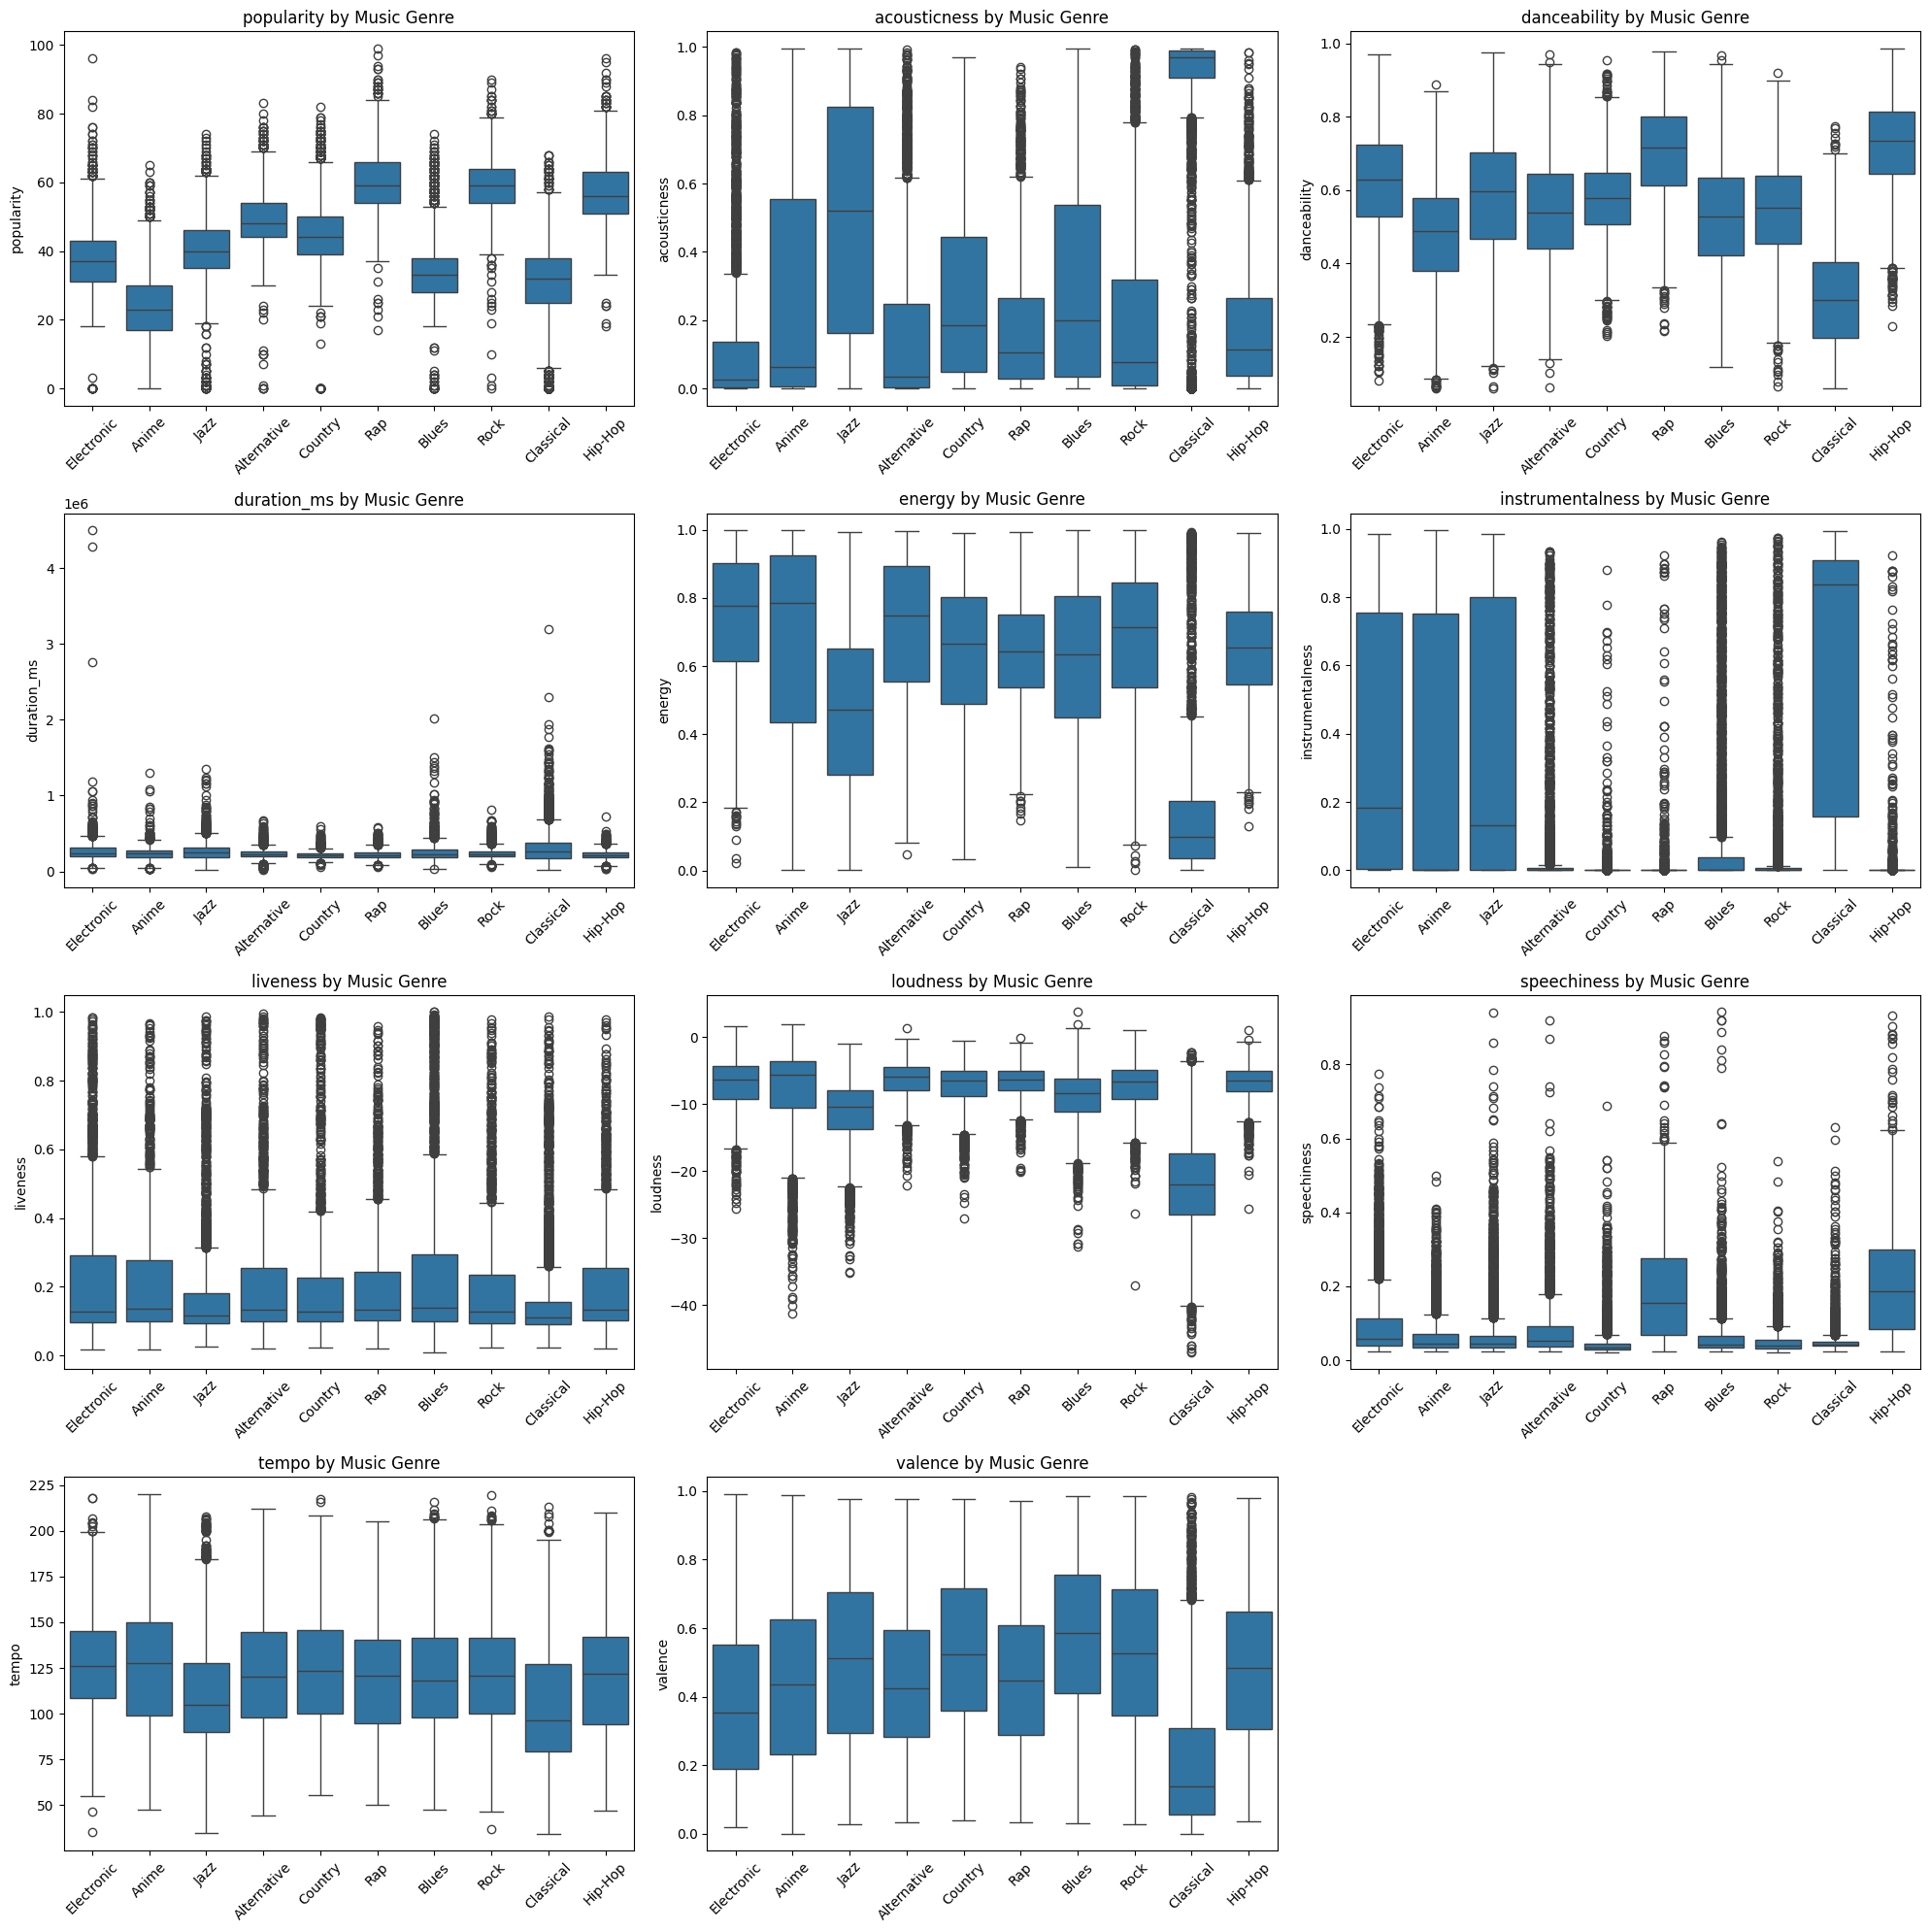

In [15]:

df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
df = df.dropna(subset=['tempo']).reset_index(drop=True)
features = ['popularity', 'acousticness', 'danceability', 'duration_ms',
            'energy', 'instrumentalness', 'liveness', 'loudness',
            'speechiness', 'tempo', 'valence']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='music_genre',
        y=feature,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} by Music Genre')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

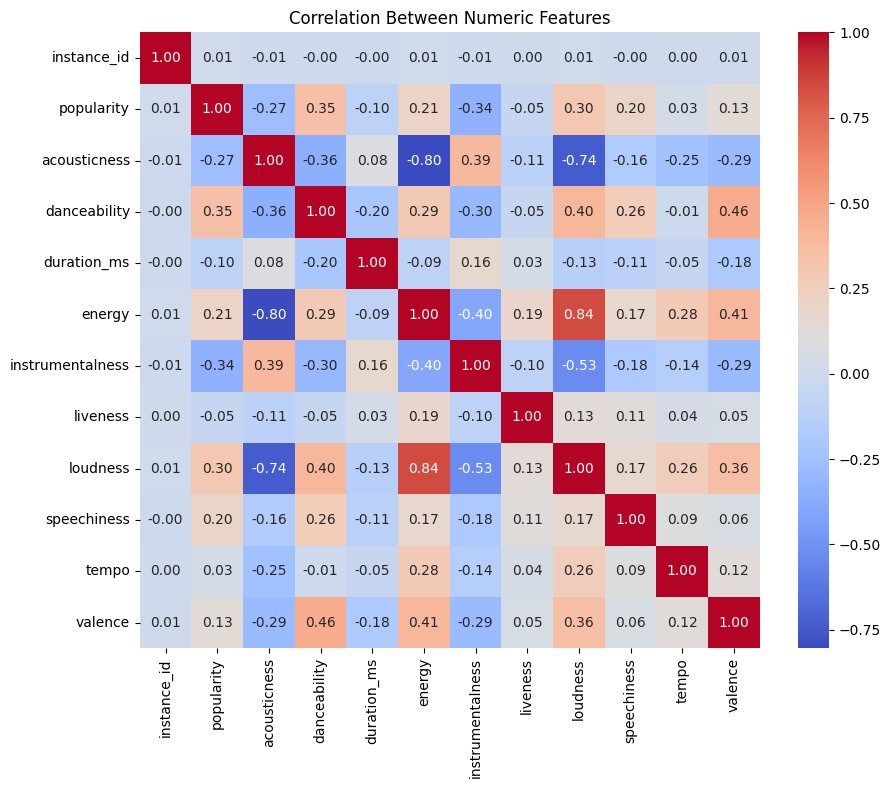

In [16]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

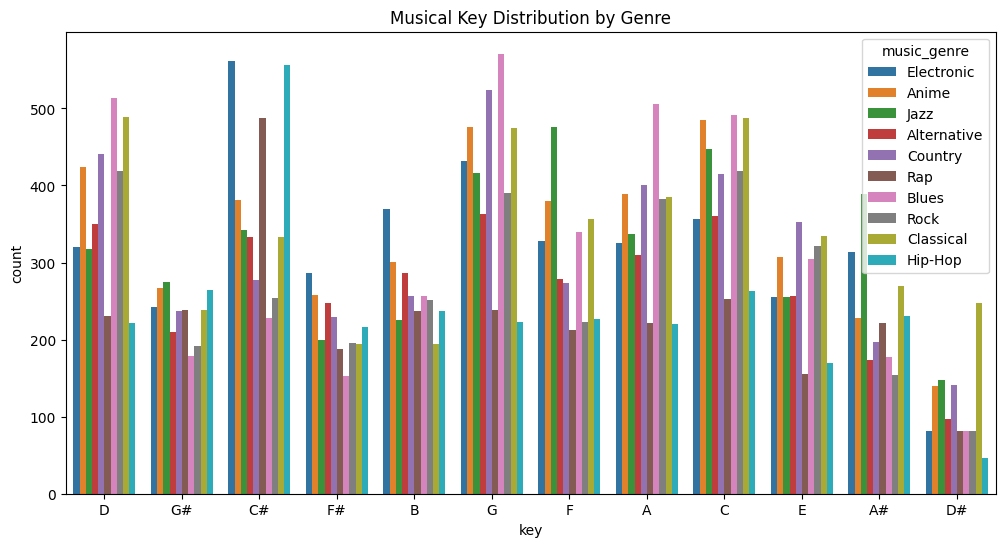

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='key', hue='music_genre')
plt.title('Musical Key Distribution by Genre')
plt.show()

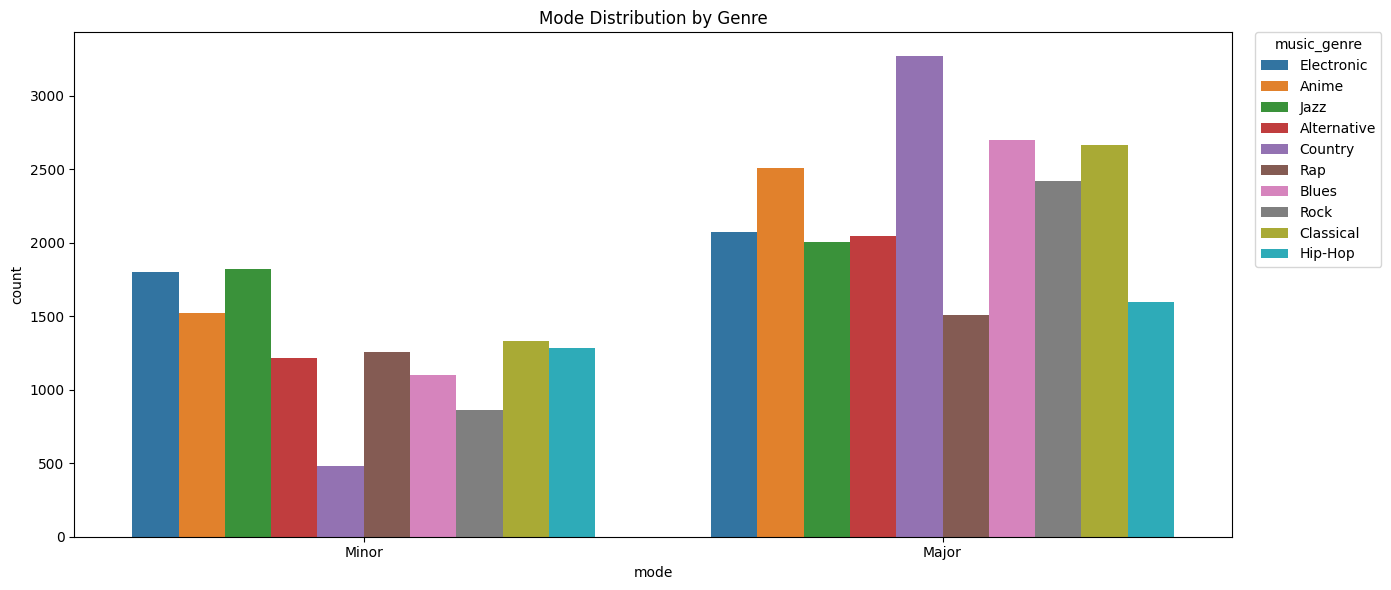

In [18]:
plt.figure(figsize=(14, 6))

ax = sns.countplot(data=df, x='mode', hue='music_genre')

plt.title('Mode Distribution by Genre')
plt.xlabel('mode')
plt.ylabel('count')

plt.legend(
    title='music_genre',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


## Feature Engineering & Feature selection

After removing duplicate and incomplete rows, we need to select features to train the model with. This section goes through encoding non-numerical values such as key and mode. First, the columns that do not provide any useful information should be dropped.

create new variables from the existingones, perform feature selection and remove unnecessary features, handle outliers, combine features from multiple datasets, etc.

In [19]:
df['duration_min'] = df['duration_ms'] / 60000
df['energy_danceability'] = df['energy'] * df['danceability']
df['energy_valence'] = df['energy'] * df['valence']
df['acoustic_instrumental'] = df['acousticness'] * df['instrumentalness']
df['energy_popularity'] = df['energy'] * df['popularity']
df['danceability_popularity'] = df['danceability'] * df['popularity']
df['valence_popularity'] = df['valence'] * df['popularity']
df['tempo'] = pd.to_numeric(df['tempo'], errors='coerce')
df = df.dropna(subset=['tempo']).reset_index(drop=True)
df['tempo_category'] = pd.cut(
    df['tempo'],
    bins=[0, 90, 120, 160, float('inf')],
    labels=['slow', 'medium', 'fast', 'very_fast']
)

In [20]:
target_col = 'music_genre'
drop_cols = [target_col,'artist_name','track_name','obtained_date','instance_id']
categorical_cols = ['key', 'mode', 'tempo_category']
# mode is binary so drop='first' removes it to one column, meaning 1 for minor and 0 for major
encoder = OneHotEncoder(drop = 'first',sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoded_cols,
    index=df.index
)
df_encoded = pd.concat([df, encoded_df], axis=1)
df_encoded = df_encoded.drop(categorical_cols, axis=1)
X = df_encoded.drop(columns=[target_col, 'artist_name', 'track_name', 'obtained_date', 'instance_id'])
y = df_encoded[target_col]

In [21]:
X.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,key_D#,key_E,key_F,key_F#,key_G,key_G#,mode_Minor,tempo_category_medium,tempo_category_slow,tempo_category_very_fast
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,0.0300,115.002,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0.0345,127.994,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0.2390,128.014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0.0413,145.036,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0.3510,149.995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Mutual Information Scores for Features:
                     Feature  MI Score
0                 popularity  0.616801
16   danceability_popularity  0.521209
15         energy_popularity  0.417632
14     acoustic_instrumental  0.322424
7                   loudness  0.299395
1               acousticness  0.299239
12       energy_danceability  0.296173
5           instrumentalness  0.285027
4                     energy  0.284964
2               danceability  0.257039
17        valence_popularity  0.255779
13            energy_valence  0.205434
8                speechiness  0.196220
9                      tempo  0.152686
3                duration_ms  0.117449
11              duration_min  0.117093
10                   valence  0.115706
29                mode_Minor  0.026277
6                   liveness  0.022914
31       tempo_category_slow  0.020846
21                    key_C#  0.008286
30     tempo_category_medium  0.007273
18                    key_A#  0.002441
23                    ke

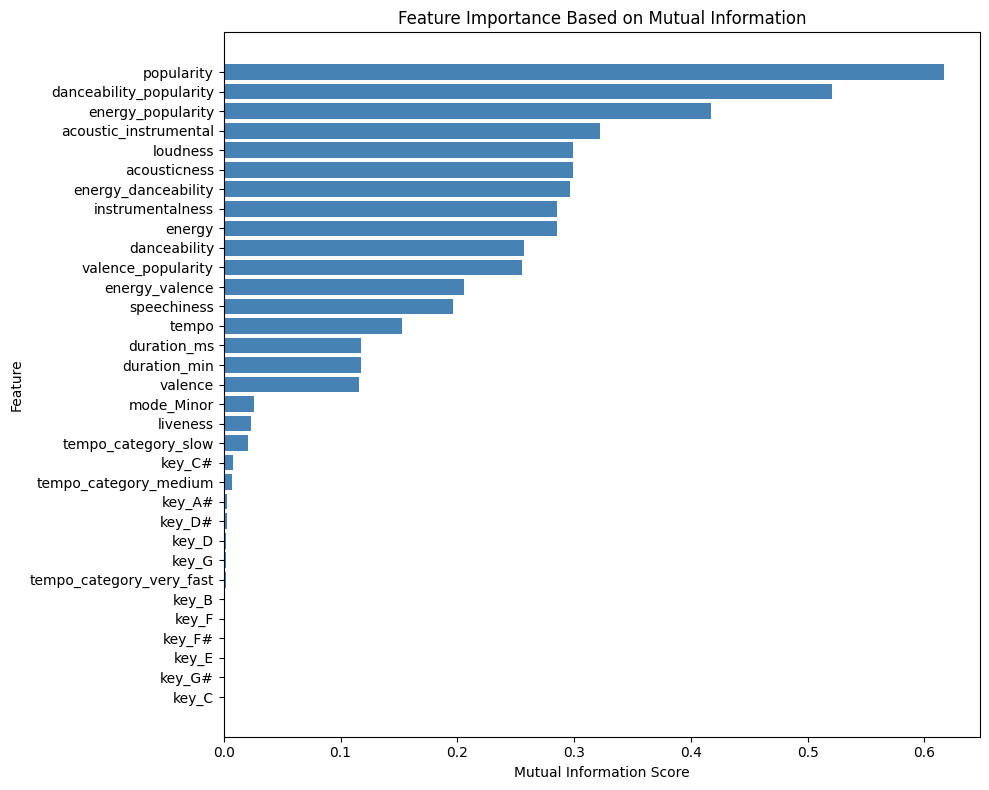

In [22]:

discrete_features = X.columns.str.startswith(('key_', 'mode_'))

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print("Mutual Information Scores for Features:")
print(mi_df)

plt.figure(figsize=(10, 8))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='steelblue')

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Feature Importance Based on Mutual Information")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Popularity was retained because it may contain useful genre-related information. Some genres may have different popularity patterns on streaming platforms, so this feature could help improve classification performance. However, popularity is not an audio characteristic, so it may reflect listener behavior or platform trends rather than the sound of the track.


A correlation heatmap for redundancy checks whether some features are giving almost the same information. Correlation does not tell you whether a feature is useful for predicting music genre. It only tells you whether two features are similar to each other.



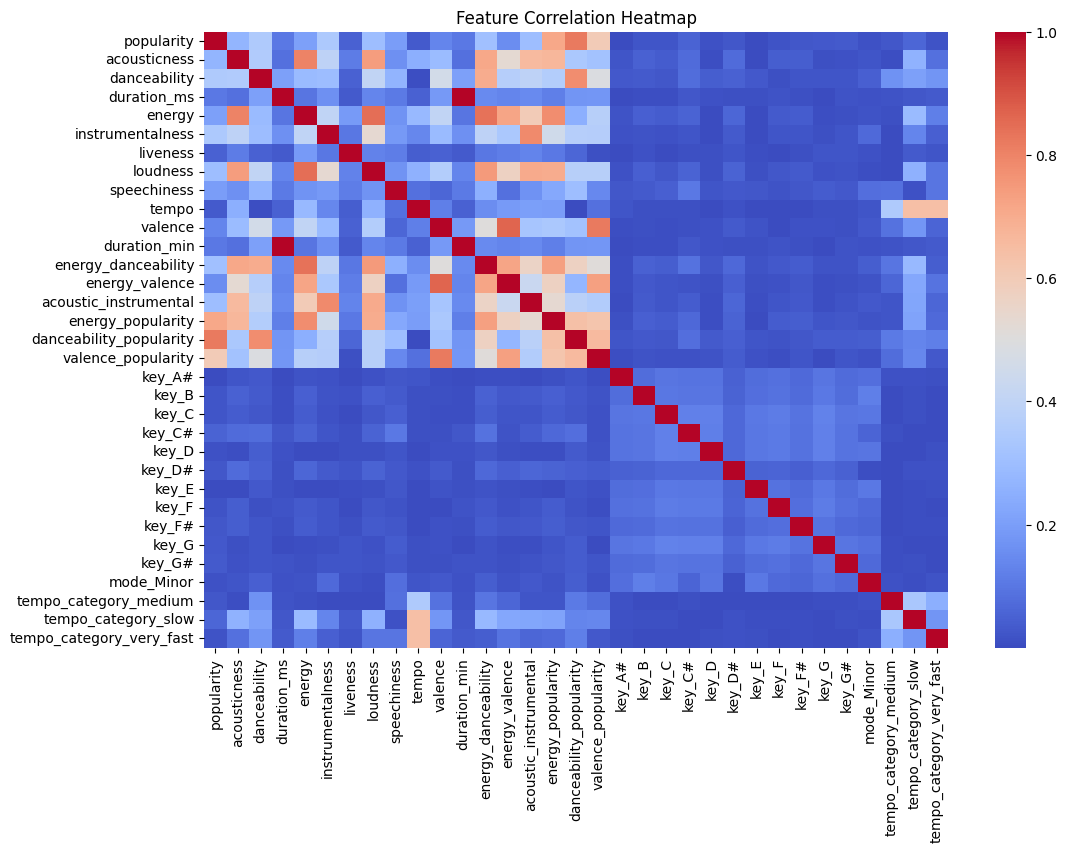

In [23]:
corr_matrix = X.corr().abs()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## Data modelling

Genre is non-numeric, so the modelling methods should be a classification method. Here, we try three modelling methos, which are KNN classification, Decision Tree and Naive Bayes.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

In [25]:
# Scale data for KNN only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(
            criterion="entropy",
            max_depth=10,
            random_state=42
        ),
        "X_train": X_train,
        "X_test": X_test
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "X_train": X_train,
        "X_test": X_test
    }
}

results = []
conf_matrices = {}

for name, info in models.items():
    model = info["model"]
    X_train_model = info["X_train"]
    X_test_model = info["X_test"]

    model.fit(X_train_model, y_train)

    y_pred = model.predict(X_test_model)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results)

print("Model Comparison Results:")
print(results_df.to_string(index=False))



KNN Classification Report:
              precision    recall  f1-score   support

 Alternative       0.25      0.38      0.30       653
       Anime       0.57      0.62      0.60       807
       Blues       0.43      0.42      0.43       760
   Classical       0.74      0.78      0.76       800
     Country       0.36      0.50      0.42       749
  Electronic       0.56      0.42      0.48       775
     Hip-Hop       0.38      0.39      0.39       576
        Jazz       0.51      0.36      0.42       765
         Rap       0.38      0.28      0.32       554
        Rock       0.49      0.36      0.41       657

    accuracy                           0.46      7096
   macro avg       0.47      0.45      0.45      7096
weighted avg       0.48      0.46      0.46      7096


Decision Tree Classification Report:
              precision    recall  f1-score   support

 Alternative       0.38      0.35      0.37       653
       Anime       0.68      0.71      0.70       807
       Blues

Seeing how the model will do with feature selection

In [26]:
k_features = 15

selector = SelectKBest(score_func=mutual_info_classif, k=k_features)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
scaler_selected = StandardScaler()

X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

models_selected = {
    "KNN + Feature Selection": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "X_train": X_train_selected_scaled,
        "X_test": X_test_selected_scaled
    },
    "Decision Tree + Feature Selection": {
        "model": DecisionTreeClassifier(
            criterion="entropy",
            max_depth=10,
            random_state=42
        ),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    },
    "Naive Bayes + Feature Selection": {
        "model": GaussianNB(),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    }
}
results_selected = []
conf_matrices_selected = {}

for name, info in models_selected.items():
    model = info["model"]
    X_train_model = info["X_train"]
    X_test_model = info["X_test"]

    model.fit(X_train_model, y_train)

    y_pred = model.predict(X_test_model)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices_selected[name] = confusion_matrix(y_test, y_pred)

    results_selected.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

results_selected_df = pd.DataFrame(results_selected)

print("Model Comparison Results:")
print(results_selected_df.to_string(index=False))



KNN + Feature Selection Classification Report:
              precision    recall  f1-score   support

 Alternative       0.33      0.41      0.36       653
       Anime       0.65      0.68      0.66       807
       Blues       0.49      0.46      0.47       760
   Classical       0.80      0.83      0.81       800
     Country       0.40      0.49      0.44       749
  Electronic       0.63      0.51      0.56       775
     Hip-Hop       0.40      0.44      0.42       576
        Jazz       0.51      0.44      0.47       765
         Rap       0.36      0.31      0.33       554
        Rock       0.52      0.47      0.49       657

    accuracy                           0.51      7096
   macro avg       0.51      0.50      0.50      7096
weighted avg       0.52      0.51      0.52      7096


Decision Tree + Feature Selection Classification Report:
              precision    recall  f1-score   support

 Alternative       0.38      0.35      0.36       653
       Anime       0.70   

Feature selection did not improve model performance. This suggests that the removed features either had little impact on the models, or that the selected features retained most of the predictive information from the full dataset.

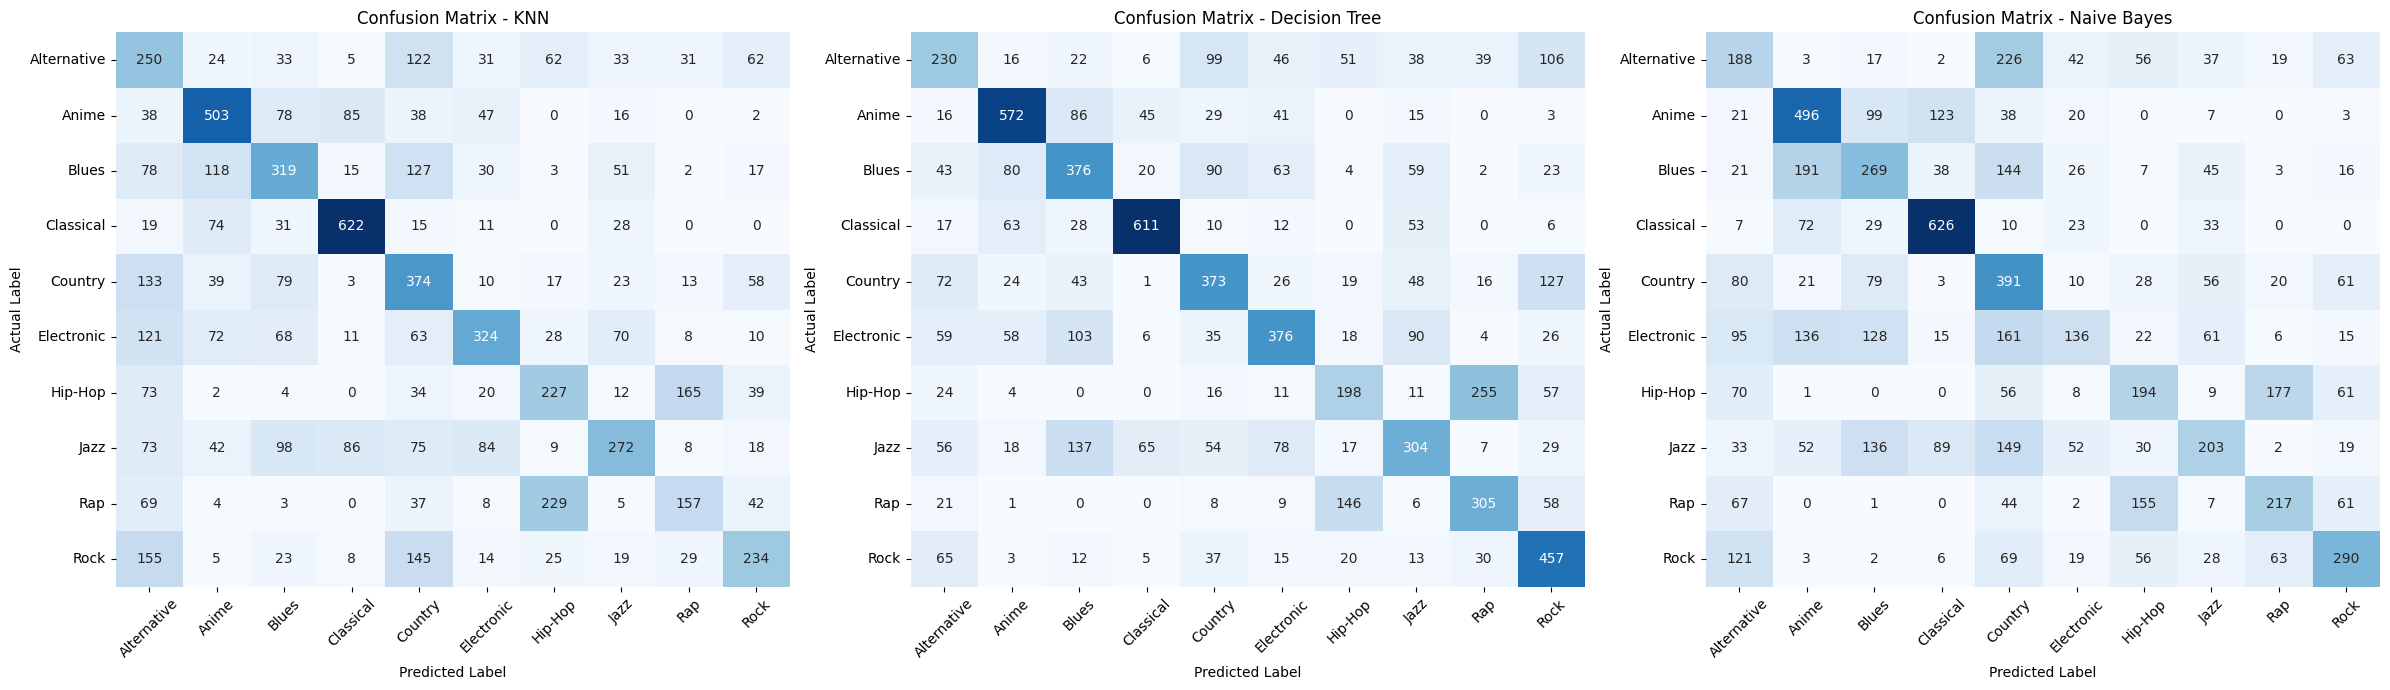

In [27]:

class_names = sorted(y.unique())

conf_matrices = {}

for name, info in models.items():
    model = info["model"]
    X_train_model = info["X_train"]
    X_test_model = info["X_test"]

    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_test_model)

    conf_matrices[name] = confusion_matrix(
        y_test,
        y_pred,
        labels=class_names
    )

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (name, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names
    )

    ax.set_title(f"Confusion Matrix - {name}", fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


#### Neural Network
A Multi-Layer Perceptron (MLP) was selected as the neural network model for this classification task. The target variable, music_genre, contains categorical class labels, so MLPClassifier is appropriate. Unlike simpler linear models, an MLP can learn non-linear relationships between audio features such as danceability, energy, tempo, acousticness, and the final genre label. This makes it useful for music genre prediction, where the relationship between features and genre may be complex.
MLP models are sensitive to the scale of input features, so the features were standardised before training. This helps the model train more effectively and prevents features with larger numeric ranges, such as duration_ms, from dominating the learning process.


In [28]:
# only one layer
mlp = MLPClassifier(max_iter=500, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.5893461104847801
              precision    recall  f1-score   support

 Alternative       0.44      0.39      0.41       653
       Anime       0.74      0.74      0.74       807
       Blues       0.59      0.51      0.55       760
   Classical       0.82      0.80      0.81       800
     Country       0.56      0.59      0.57       749
  Electronic       0.66      0.57      0.61       775
     Hip-Hop       0.48      0.38      0.43       576
        Jazz       0.52      0.59      0.55       765
         Rap       0.44      0.56      0.49       554
        Rock       0.57      0.66      0.61       657

    accuracy                           0.59      7096
   macro avg       0.58      0.58      0.58      7096
weighted avg       0.59      0.59      0.59      7096



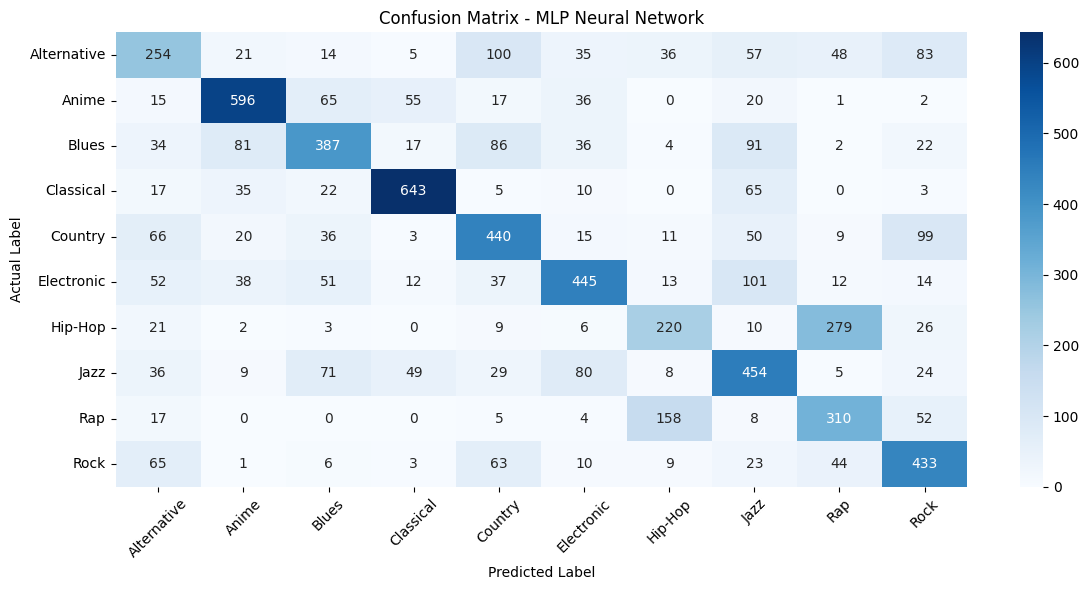

In [29]:
class_names = sorted(y_test.unique())

cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=class_names
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - MLP Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# let's try with more layers and neurons
mlp = MLPClassifier(hidden_layer_sizes=(265, 128, 64), max_iter=200, random_state=42, verbose=True)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp.fit(X_train_scaled, y_train)


Iteration 1, loss = 1.37839252
Iteration 2, loss = 1.14357951
Iteration 3, loss = 1.10027026
Iteration 4, loss = 1.06936893
Iteration 5, loss = 1.04665629
Iteration 6, loss = 1.02349035
Iteration 7, loss = 1.00094833
Iteration 8, loss = 0.98663322
Iteration 9, loss = 0.97442456
Iteration 10, loss = 0.95714932
Iteration 11, loss = 0.94471276
Iteration 12, loss = 0.93232034
Iteration 13, loss = 0.92338768
Iteration 14, loss = 0.91216892
Iteration 15, loss = 0.90209825
Iteration 16, loss = 0.89317063
Iteration 17, loss = 0.88132946
Iteration 18, loss = 0.86991123
Iteration 19, loss = 0.86419761
Iteration 20, loss = 0.85258547
Iteration 21, loss = 0.84572049
Iteration 22, loss = 0.83287443
Iteration 23, loss = 0.82216661
Iteration 24, loss = 0.81353810
Iteration 25, loss = 0.80586812
Iteration 26, loss = 0.79598867
Iteration 27, loss = 0.78765959
Iteration 28, loss = 0.77890597
Iteration 29, loss = 0.76807265
Iteration 30, loss = 0.76709359
Iteration 31, loss = 0.75198904
Iteration 32, los

/Users/lipuze/miniconda3/envs/brain/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(265, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [33]:
y_pred_mlp = mlp.predict(X_test_scaled)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

MLP Accuracy: 0.5288895152198422
              precision    recall  f1-score   support

 Alternative       0.32      0.24      0.27       653
       Anime       0.73      0.68      0.71       807
       Blues       0.46      0.48      0.47       760
   Classical       0.81      0.77      0.79       800
     Country       0.52      0.50      0.51       749
  Electronic       0.55      0.55      0.55       775
     Hip-Hop       0.44      0.51      0.47       576
        Jazz       0.46      0.57      0.51       765
         Rap       0.40      0.35      0.37       554
        Rock       0.49      0.52      0.50       657

    accuracy                           0.53      7096
   macro avg       0.52      0.52      0.52      7096
weighted avg       0.53      0.53      0.53      7096



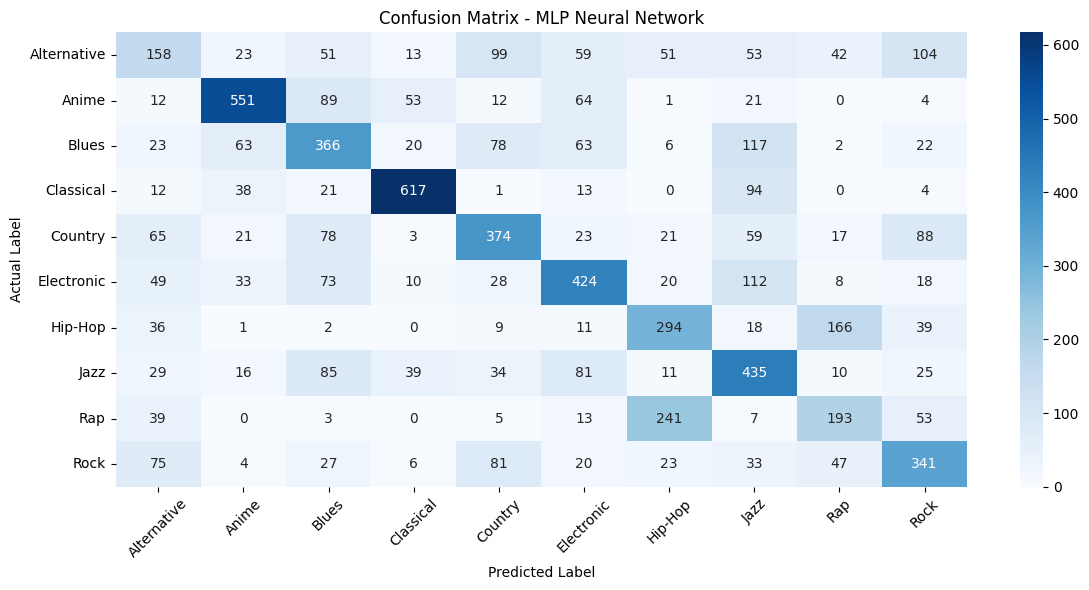

In [34]:
class_names = sorted(y_test.unique())

cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=class_names
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix - MLP Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()